# Example 1 — Neutrino trident events with `neptune`

`neptune` computes the SM and BSM neutrino-trident process
$$
    \nu_\alpha + N \to \nu_\alpha + \ell_1^- + \ell_2^+ + N\,,
$$
in the **coherent** (Woods-Saxon nuclear form factor, $\propto Z^2$) and **diffractive** (nucleon dipole form factor, $\propto A$, with Pauli blocking) regimes. The squared matrix element is derived symbolically with FeynCalc in [`mathematica/BSM_trident.nb`](../mathematica/BSM_trident.nb) — that notebook is the canonical source for everything the Python integrators consume.

This notebook walks through:

1. Building Standard Model and BSM ($Z'$) trident models.
2. Computing total cross sections at a fixed neutrino energy, including a 1D energy scan.
3. Comparing different lepton-flavor channels.
4. Scanning over $(M_{Z'},\,g')$ parameter space.
5. Generating weighted Monte Carlo events with the `TridentGenerator`.
6. Choosing a nuclear form factor and comparing the EPA vs. full coherent integration.


In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import neptune as nep
print('neptune', nep.__version__)

neptune 0.1.0


## 1) A first cross-section calculation

We start with the dimuon trident channel $\nu_\mu + \mathrm{Ar} \to \nu_\mu \mu^+ \mu^- \mathrm{Ar}$ at $E_\nu = 10\,\mathrm{GeV}$.

The model encapsulates the SM $W+Z$ structure. The process object glues the model to a target nucleus and runs `vegas` to integrate the 6-dim equivalent-photon-approximation phase space.

In [2]:
model = nep.TridentSMModel(nu_flavor='mu', l1_flavor='mu', l2_flavor='mu')
print(model)

# Argon-40
proc = nep.TridentProcess(model, Z=18, A=40, Enu=10.0, nitn=8, neval=20_000)
result = proc.sigma_total()
for k, (mean, sd) in result.items():
    print(f'{k:>22s}: {mean:.3e}  +/-  {sd:.2e}  cm^2')

TridentSMModel(nu=mu, l1=mu, l2=mu, nubar=False)
           diffractive: 9.513e-44  +/-  1.52e-46  cm^2
              coherent: 5.250e-42  +/-  6.60e-45  cm^2
     total_per_nucleus: 6.963e-42  +/-  7.15e-45  cm^2


## 2) Energy scan: $\sigma(E_\nu)$

We sweep $E_\nu$ from a few GeV (above threshold) to ~100 GeV and overlay the coherent and diffractive components. The coherent piece dominates for moderate-mass targets thanks to its $Z^2$ enhancement, but diffractive scattering takes over at the highest energies for heavy targets.

/Users/mhostert/Repos/neptune/src/neptune/nuclear_tools.py:203: RuntimeWarning: overflow encountered in sinh
  den = safe_q**3 * np.sinh(np.pi * safe_q * a) * (r0**2 + np.pi**2 * a**2) * r0
/Users/mhostert/Repos/neptune/src/neptune/nuclear_tools.py:203: RuntimeWarning: overflow encountered in multiply
  den = safe_q**3 * np.sinh(np.pi * safe_q * a) * (r0**2 + np.pi**2 * a**2) * r0


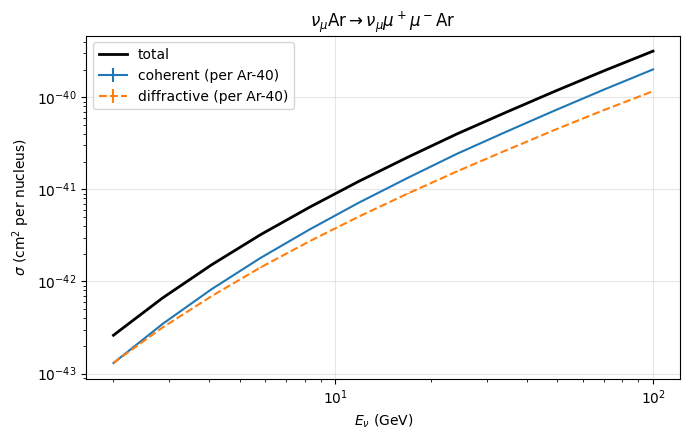

In [3]:
Enu_arr = np.geomspace(2.0, 100.0, 12)
scan = proc.sigma_scan(Enu_arr, nitn=6, neval=10_000)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(Enu_arr, scan['coherent'], yerr=scan['coherent_err'], label='coherent (per Ar-40)')
ax.errorbar(Enu_arr, scan['diffractive'] * proc.A, yerr=scan['diffractive_err'] * proc.A,
             label='diffractive (per Ar-40)', ls='--')
total = scan['coherent'] + scan['diffractive'] * proc.A
ax.plot(Enu_arr, total, 'k-', label='total', lw=2)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$E_\nu$ (GeV)'); ax.set_ylabel(r'$\sigma$ (cm$^2$ per nucleus)')
ax.set_title(r'$\nu_\mu \mathrm{Ar} \to \nu_\mu \mu^+ \mu^- \mathrm{Ar}$')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()

## 3) Channel comparison

Different lepton-flavor combinations have very different SM coupling structures (through $V_{ijk}$ and $A_{ijk}$). We compare three benchmark channels at a fixed energy.

In [4]:
channels = [
    ('mu', 'mu', 'mu'),   # NC-only,  same flavor
    ('e',  'e',  'e'),    # NC + CC interference
    ('mu', 'mu', 'e'),    # mixed (no CC at all)
    ('e',  'e',  'mu'),   # CC dominant
]
rows = []
for nu, l1, l2 in channels:
    m = nep.TridentSMModel(nu_flavor=nu, l1_flavor=l1, l2_flavor=l2)
    p = nep.TridentProcess(m, Z=18, A=40, Enu=20.0, nitn=6, neval=10_000)
    coh, coh_e = p.sigma_coherent()
    dif, dif_e = p.sigma_diffractive()
    rows.append(dict(channel=f'nu_{nu} -> {l1}-{l2}+',
                     sigma_coh=coh, sigma_diff_per_nucleon=dif))
df_ch = pd.DataFrame(rows)
df_ch

,channel,sigma_coh,sigma_diff_per_nucleon
0,nu_mu -> mu-mu+,1.778407e-41,2.960300e-43
1,nu_e -> e-e+,7.572646e-41,3.805002e-43
2,nu_mu -> mu-e+,8.630283e-41,5.986928e-43
3,nu_e -> e-mu+,5.878954e-41,5.864611e-43


## 4) BSM $Z'$ scan

The `TridentBSMModel` adds a vector $Z'$ that couples to charged leptons (and, in our example here, to the nucleus through the $\mathrm{CHARGE}=Z$ assignment in coherent scattering). We hold $g' = 10^{-3}$ and scan in $M_{Z'}$ to see the propagator-driven enhancement at low mass.

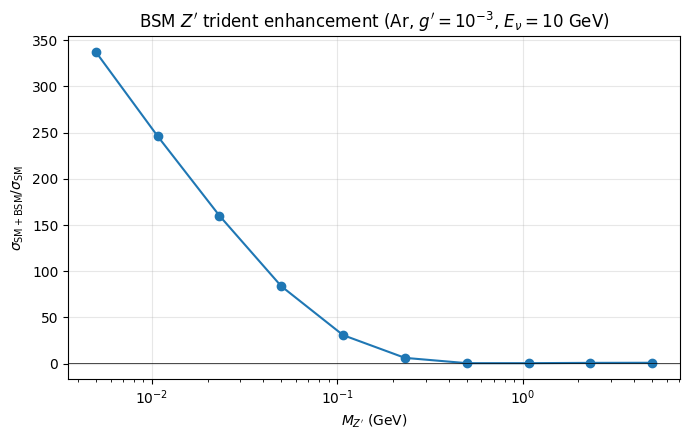

In [5]:
mzprime_arr = np.geomspace(0.005, 5.0, 10)
gprime = 1e-3
Z, A = 18, 40

sm_model = nep.TridentSMModel(nu_flavor='mu', l1_flavor='mu', l2_flavor='mu')
sm_proc = nep.TridentProcess(sm_model, Z=Z, A=A, Enu=10.0, nitn=6, neval=10_000)
sm_coh, _ = sm_proc.sigma_coherent()

ratios = []
for mz in mzprime_arr:
    bsm = nep.TridentBSMModel(
        nu_flavor='mu', l1_flavor='mu', l2_flavor='mu',
        mzprime=mz, gV_prime=gprime, gA_prime=0.0, CHARGE=Z,
    )
    p = nep.TridentProcess(bsm, Z=Z, A=A, Enu=10.0, nitn=6, neval=10_000)
    coh, _ = p.sigma_coherent()
    ratios.append(coh / sm_coh)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(mzprime_arr, ratios, 'o-')
ax.axhline(1.0, color='k', lw=0.5)
ax.set_xscale('log')
ax.set_xlabel(r"$M_{Z'}$ (GeV)"); ax.set_ylabel(r'$\sigma_\mathrm{SM+BSM} / \sigma_\mathrm{SM}$')
ax.set_title(r"BSM $Z'$ trident enhancement (Ar, $g'=10^{-3}$, $E_\nu=10$ GeV)")
ax.grid(alpha=0.3)
plt.tight_layout()

## 5) Generate weighted MC events

The `TridentGenerator` trains a `vegas` importance-sampling map and samples weighted events for both the diffractive and coherent regimes. The output dict gives the kinematic invariants on the unit phase-space hypercube together with `weight` (proportional to $d\sigma$) and `mode` (`'diffractive'` or `'coherent'`).

Here we wrap the dict in a DarkNews-style `pandas.DataFrame` so it can be analysed and merged easily with DarkNews outputs.

In [6]:
model = nep.TridentSMModel(nu_flavor='mu', l1_flavor='mu', l2_flavor='mu')
gen = nep.TridentGenerator(
    model, Z=18, A=40, Enu=10.0,
    n_events=5_000, nitn=6, neval=20_000, seed=0,
)
events = gen.generate(verbose=False)

df = pd.DataFrame({
    'x1':                events['x1'],   # Q^2  [GeV^2]
    'x2':                events['x2'],   # p_nu . (P_N - P'_N)  [GeV^2]
    'x3':                events['x3'],   # q . p_l2  [GeV^2]
    'x4':                events['x4'],   # q . p_l1  [GeV^2]
    'x5':                events['x5'],   # p_nu . p_l2  [GeV^2]
    'x6':                events['x6'],   # p'_nu . p_l1  [GeV^2]
    'm6':                events['m6'],   # auxiliary dilepton-kinematic variable
    'Enu':               events['Enu'],
    'w_event_rate':      events['weight'],
    'scattering_regime': events['mode'],
})
df.attrs['model'] = repr(model)
df.attrs['target_pdgid'] = 1000180400  # Ar-40
print(f'Total events: {len(df)},  weight sum (cm^2 per Ar-40): {df["w_event_rate"].sum():.3e}')
df.head()

Total events: 33726,  weight sum (cm^2 per Ar-40): 5.336e-42


,x1,x2,x3,x4,x5,x6,m6,Enu,w_event_rate,scattering_regime
0,0.033834,0.508432,0.148584,0.130194,0.020077,0.293071,0.195284,10.0,5.921384e-48,diffractive
1,0.000111,0.039446,0.026552,0.008032,0.008847,0.029171,0.001429,10.0,4.389290e-51,diffractive
2,0.038102,0.523929,0.120601,0.009778,0.040349,0.457351,0.026230,10.0,7.338828e-48,diffractive
3,0.000112,0.047780,0.020409,0.014254,0.014079,0.025510,0.008191,10.0,4.242355e-50,diffractive
4,0.017823,0.176628,0.057874,0.002555,0.022524,0.148676,0.005429,10.0,5.951102e-48,diffractive


### Kinematic distributions

We can plot the photon virtuality $Q^2 = x_1$ and the auxiliary dilepton-kinematic variable $m_6$ for both regimes.

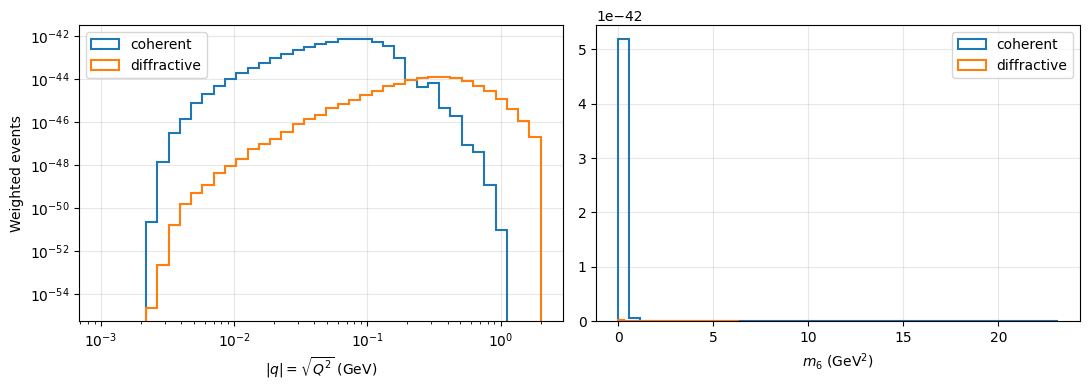

In [7]:
regimes = ['coherent', 'diffractive']
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for r in regimes:
    sel = df['scattering_regime'] == r
    Q   = np.sqrt(np.maximum(df['x1'][sel], 0.0))   # |q| = sqrt(Q^2)
    w   = df['w_event_rate'][sel]
    axes[0].hist(Q,                bins=np.geomspace(1e-3, 2.0, 40),
                  weights=w, histtype='step', label=r, lw=1.5)
    axes[1].hist(df['m6'][sel],    bins=40,
                  weights=w, histtype='step', label=r, lw=1.5)

axes[0].set_xlabel(r'$|q| = \sqrt{Q^2}$ (GeV)')
axes[0].set_xscale('log'); axes[0].set_yscale('log')
axes[0].set_ylabel('Weighted events')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_xlabel(r'$m_6$ (GeV$^2$)')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()

## 6) Coherent nuclear form factors

The coherent piece carries an explicit nuclear form factor $F(Q^2)$, normalised so $F(0)=1$. neptune ships two parametrisations:

* `'woods-saxon'` (default): the analytic Woods–Saxon Fourier transform — A-only, identical to the C++ reference. Smooth and parameter-free.
* `'darknews'`: the DarkNews per-nucleus form factor. Where the Fourier–Bessel coefficients have been measured (Nuclear Data Tables; covers most stable isotopes), it uses those directly; otherwise it falls back to a symmetrised Fermi profile keyed by $A$.

You can also pass any callable `f(Q^2)` of your own (e.g. a Helm form factor or a custom parametrisation).

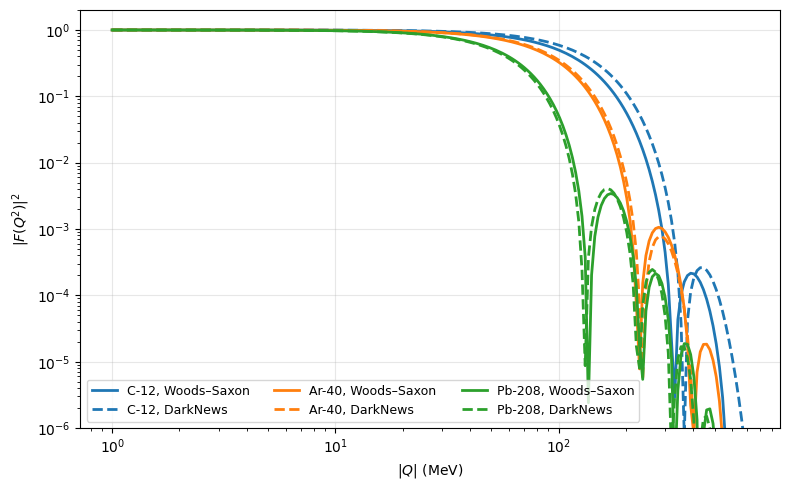

In [8]:
# Compare F(Q^2) for the two parametrisations on three nuclei
Q2_grid = np.geomspace(1e-6, 5e-1, 200)   # GeV^2
Q_grid_MeV = np.sqrt(Q2_grid) * 1e3

fig, ax = plt.subplots(figsize=(8, 5))
for name, Z, A, color in [('C-12', 6, 12, 'C0'), ('Ar-40', 18, 40, 'C1'), ('Pb-208', 82, 208, 'C2')]:
    F_ws = nep.get_form_factor('woods-saxon', Z=Z, A=A)
    F_dn = nep.get_form_factor('darknews',    Z=Z, A=A)
    ax.plot(Q_grid_MeV, F_ws(Q2_grid)**2, color=color, lw=2, label=f'{name}, Woods–Saxon')
    ax.plot(Q_grid_MeV, F_dn(Q2_grid)**2, color=color, lw=2, ls='--', label=f'{name}, DarkNews')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$|Q|$ (MeV)')
ax.set_ylabel(r'$|F(Q^2)|^2$')
ax.set_ylim(1e-6, 2)
ax.legend(ncol=3, fontsize=9, loc='lower left'); ax.grid(alpha=0.3)
plt.tight_layout()

In [9]:
# Coherent dimuon trident xsec at E_nu = 10 GeV for both choices
model_ff = nep.TridentSMModel(nu_flavor='mu', l1_flavor='mu', l2_flavor='mu')
rows = []
for name, Z, A in [('C-12', 6, 12), ('Ar-40', 18, 40), ('Fe-56', 26, 56), ('Pb-208', 82, 208)]:
    out = {'target': name, 'Z': Z, 'A': A}
    for ff in ['woods-saxon', 'darknews']:
        proc = nep.TridentProcess(model_ff, Z=Z, A=A, Enu=10.0,
                                  form_factor=ff, nitn=6, neval=10_000)
        coh, sd = proc.sigma_coherent()
        out[f'sigma_coh ({ff})'] = coh
    out['ratio (DN / WS)'] = out['sigma_coh (darknews)'] / out['sigma_coh (woods-saxon)']
    rows.append(out)
df_ff = pd.DataFrame(rows)
df_ff.style.format({c: '{:.3e}' for c in df_ff.columns if 'sigma' in c}
                    | {'ratio (DN / WS)': '{:.3f}'})

,target,Z,A,sigma_coh (woods-saxon),sigma_coh (darknews),ratio (DN / WS)
0,C-12,6,12,8.795e-43,1.085e-42,1.233
1,Ar-40,18,40,5.269e-42,5.533e-42,1.050
2,Fe-56,26,56,9.558e-42,9.933e-42,1.039
3,Pb-208,82,208,4.896e-41,4.645e-41,0.949


/Users/mhostert/Repos/neptune/src/neptune/nuclear_tools.py:203: RuntimeWarning: overflow encountered in sinh
  den = safe_q**3 * np.sinh(np.pi * safe_q * a) * (r0**2 + np.pi**2 * a**2) * r0
/Users/mhostert/Repos/neptune/src/neptune/nuclear_tools.py:203: RuntimeWarning: overflow encountered in multiply
  den = safe_q**3 * np.sinh(np.pi * safe_q * a) * (r0**2 + np.pi**2 * a**2) * r0


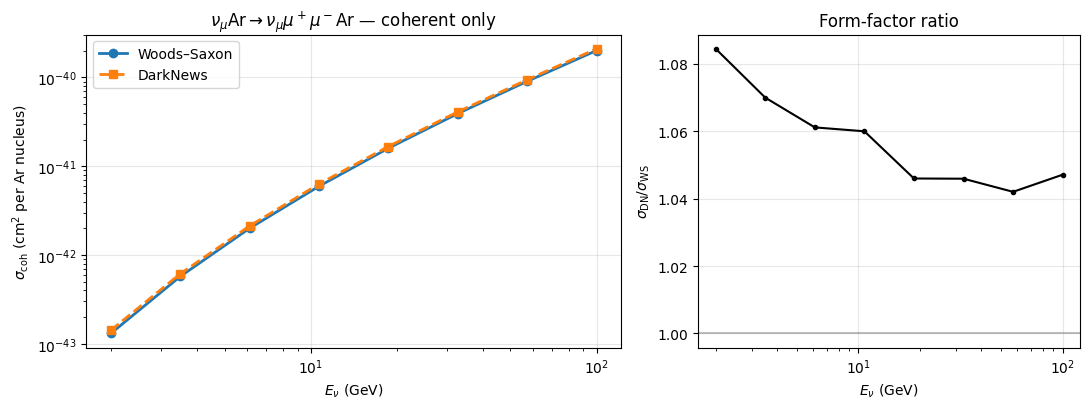

In [10]:
# Energy scan on Argon comparing the two form-factor choices
Enu_scan = np.geomspace(2.0, 100.0, 8)
sig_ws = np.zeros_like(Enu_scan)
sig_dn = np.zeros_like(Enu_scan)
for i, E in enumerate(Enu_scan):
    p_ws = nep.TridentProcess(model_ff, Z=18, A=40, Enu=E,
                              form_factor='woods-saxon', nitn=6, neval=8_000)
    p_dn = nep.TridentProcess(model_ff, Z=18, A=40, Enu=E,
                              form_factor='darknews',    nitn=6, neval=8_000)
    sig_ws[i] = p_ws.sigma_coherent()[0]
    sig_dn[i] = p_dn.sigma_coherent()[0]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), gridspec_kw={'width_ratios': [1.4, 1]})
axes[0].plot(Enu_scan, sig_ws, 'o-',  label='Woods–Saxon', lw=2)
axes[0].plot(Enu_scan, sig_dn, 's--', label='DarkNews',    lw=2)
axes[0].set_xscale('log'); axes[0].set_yscale('log')
axes[0].set_xlabel(r'$E_\nu$ (GeV)')
axes[0].set_ylabel(r'$\sigma_\mathrm{coh}$ (cm$^2$ per Ar nucleus)')
axes[0].set_title(r'$\nu_\mu \mathrm{Ar} \to \nu_\mu \mu^+ \mu^- \mathrm{Ar}$ — coherent only')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(Enu_scan, sig_dn / sig_ws, 'k.-')
axes[1].axhline(1.0, color='gray', alpha=0.5)
axes[1].set_xscale('log')
axes[1].set_xlabel(r'$E_\nu$ (GeV)')
axes[1].set_ylabel(r'$\sigma_\mathrm{DN} / \sigma_\mathrm{WS}$')
axes[1].set_title('Form-factor ratio')
axes[1].grid(alpha=0.3)
plt.tight_layout()

## 7) Three integration modes: `full`, `improved-epa`, `epa`

`TridentProcess` and `TridentGenerator` accept a `mode` argument that selects how the differential cross section is assembled from the T/L decomposition $d\sigma \propto h_T\,\sigma_T + h_L\,\sigma_L$:

- `mode='full'` (default) — keep both transverse and longitudinal photon contributions with full $Q^2$ dependence in the leptonic $\sigma_T(Q^2,\dots)$.
- `mode='improved-epa'` — drop $h_L\,\sigma_L$ but keep $\sigma_T(Q^2,\dots)$.
- `mode='epa'` — drop $h_L\,\sigma_L$ **and** evaluate $\sigma_T$ at $Q^2=0$ (the strict equivalent-photon limit).

All three integrate over the same 8-D $x_1\dots x_6 + x_7,x_8$ phase space; the only difference is which terms are kept and where $\sigma_T$ is evaluated. Below we cross-check on Argon at a few energies.

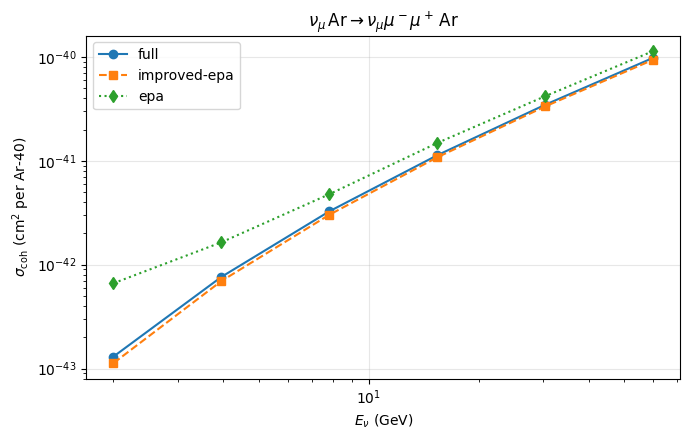

improved-epa   / full ratios: [0.865 0.913 0.926 0.955 0.964 0.959]
epa            / full ratios: [5.082 2.153 1.462 1.313 1.209 1.161]


In [11]:
Enu_full = np.geomspace(2.0, 60.0, 6)
model_ff = nep.TridentSMModel(nu_flavor='mu', l1_flavor='mu', l2_flavor='mu')
modes = ['full', 'improved-epa', 'epa']
sig = {m: np.zeros_like(Enu_full) for m in modes}

for i, E in enumerate(Enu_full):
    for m in modes:
        p = nep.TridentProcess(model_ff, Z=18, A=40, Enu=E,
                                mode=m, nitn=5, neval=8_000)
        sig[m][i] = p.sigma_coherent()[0]

fig, ax = plt.subplots(figsize=(7, 4.5))
styles = {'full': 'o-', 'improved-epa': 's--', 'epa': 'd:'}
for m in modes:
    ax.plot(Enu_full, sig[m], styles[m], label=m)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$E_\nu$ (GeV)')
ax.set_ylabel(r'$\sigma_\text{coh}$ (cm$^2$ per Ar-40)')
ax.set_title(r'$\nu_\mu\,\mathrm{Ar}\to\nu_\mu\mu^-\mu^+\,\mathrm{Ar}$')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

for m in ('improved-epa', 'epa'):
    print(f'{m:14s} / full ratios:', np.round(sig[m] / sig['full'], 3))

## 8) Where to go next

* Pass a `flux=callable(E_nu)` together with `Emin`/`Emax` to `TridentProcess` or `TridentGenerator` to flux-average and fold in a beam spectrum.
* Switch nuclei via `Z`, `A` (or pull a `NuclearTarget` via `nep.get_nuclear_target('Ar40')`).
* Use the `bsm_mode` attribute of `TridentBSMModel` to isolate SM-only, interference, or BSM-only contributions.
* The symbolic origin of every coherent / diffractive cross section in this notebook is [`mathematica/BSM_trident.nb`](../mathematica/BSM_trident.nb) — re-evaluate it in Mathematica if you need to extend the underlying matrix element.
